# Get the Data

In [81]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_bike_sharing_data():
    return pd.read_csv(Path("datasets/bike+sharing+dataset/day.csv"))

bike_sharing_full = load_bike_sharing_data()

# Review the Data Structure

In [82]:
bike_sharing_full.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [83]:
bike_sharing_full = bike_sharing_full.set_index("instant")

In [84]:
bike_sharing_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 731 entries, 1 to 731
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      731 non-null    object 
 1   season      731 non-null    int64  
 2   yr          731 non-null    int64  
 3   mnth        731 non-null    int64  
 4   holiday     731 non-null    int64  
 5   weekday     731 non-null    int64  
 6   workingday  731 non-null    int64  
 7   weathersit  731 non-null    int64  
 8   temp        731 non-null    float64
 9   atemp       731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  casual      731 non-null    int64  
 13  registered  731 non-null    int64  
 14  cnt         731 non-null    int64  
dtypes: float64(4), int64(10), object(1)
memory usage: 91.4+ KB


In [85]:
bike_sharing_full.describe()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [86]:
bike_sharing_full["holiday"].value_counts()

holiday
0    710
1     21
Name: count, dtype: int64

In [87]:
bike_sharing_full["season"].value_counts()

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

In [88]:
bike_sharing_full["weekday"].value_counts()

weekday
6    105
0    105
1    105
2    104
3    104
4    104
5    104
Name: count, dtype: int64

In [89]:
bike_sharing_full["workingday"].value_counts()

workingday
1    500
0    231
Name: count, dtype: int64

In [90]:
bike_sharing_full["weathersit"].value_counts()

weathersit
1    463
2    247
3     21
Name: count, dtype: int64

In [91]:
bike_sharing_full["yr"].value_counts()

yr
1    366
0    365
Name: count, dtype: int64

In [92]:
bike_sharing_full["mnth"].value_counts()

mnth
1     62
3     62
5     62
7     62
8     62
10    62
12    62
4     60
6     60
9     60
11    60
2     57
Name: count, dtype: int64

In [93]:
bike_sharing_full = bike_sharing_full.drop(columns=["dteday"])
bike_sharing_full.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,,,,,,,,,,,,,,
1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [94]:
bike_sharing_full["casualRatio"] = bike_sharing_full["casual"] / bike_sharing_full["registered"]
bike_sharing_full.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,casualRatio
instant,,,,,,,,,,,,,,,
1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,0.506116
2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,0.195522
3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,0.097640
4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,0.074278
5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,0.054018


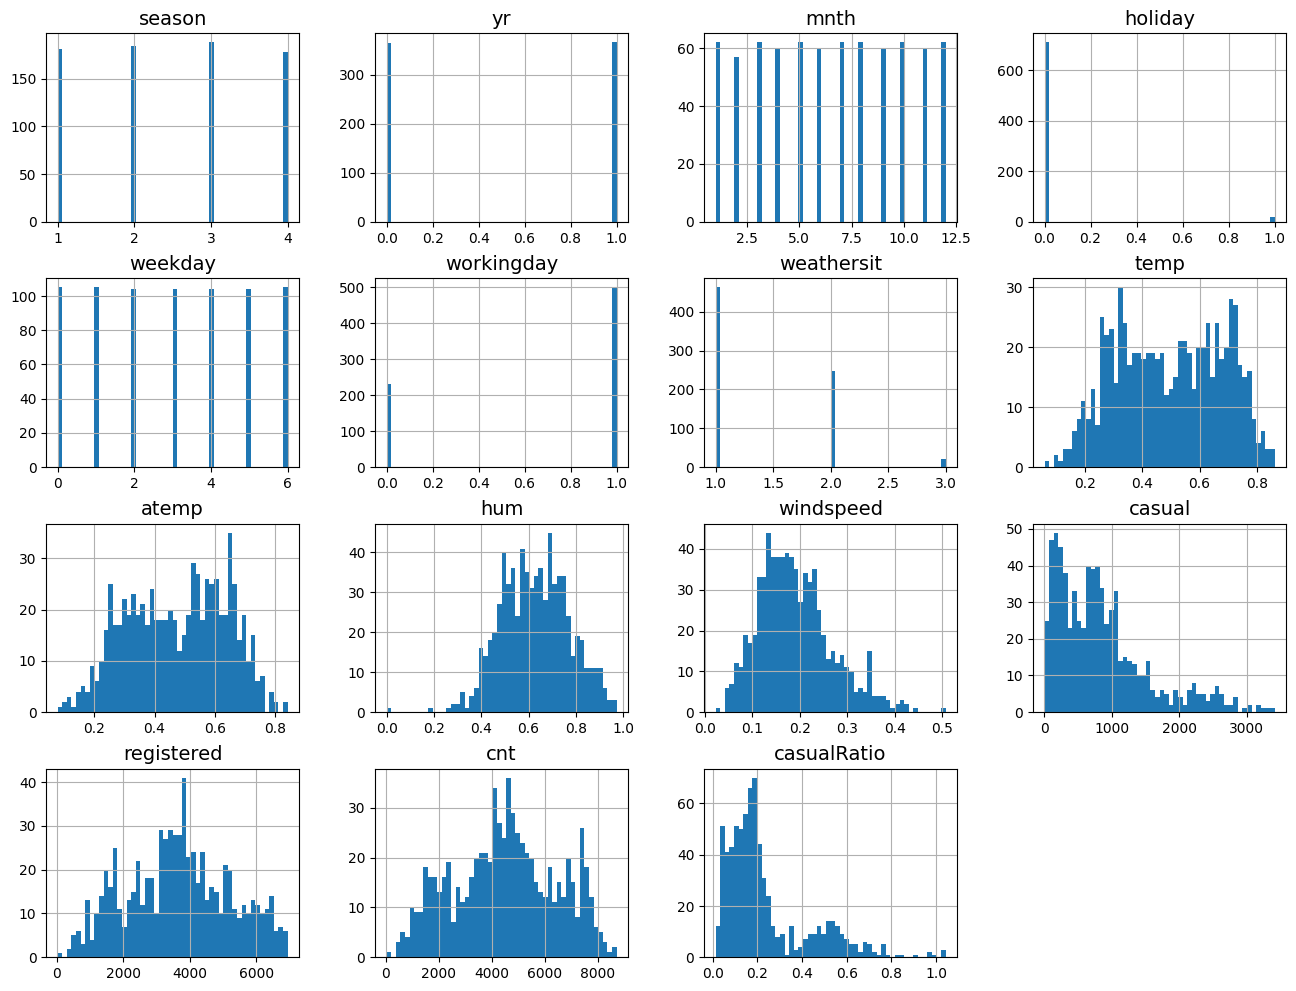

In [95]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

bike_sharing_full.hist(bins=50, figsize=(16, 12))

plt.show()

## Create a Test Set

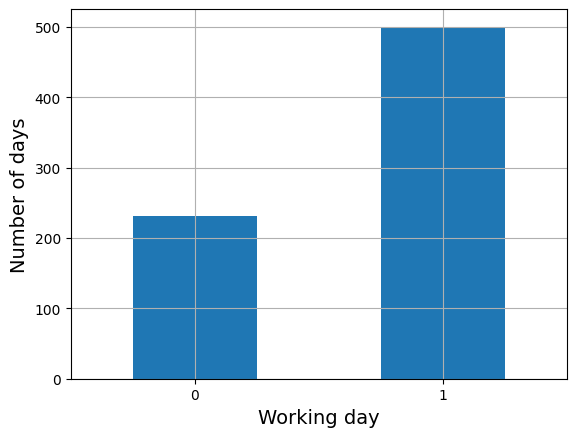

In [96]:
cat_counts = bike_sharing_full["workingday"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Working day")
plt.ylabel("Number of days")

plt.show()

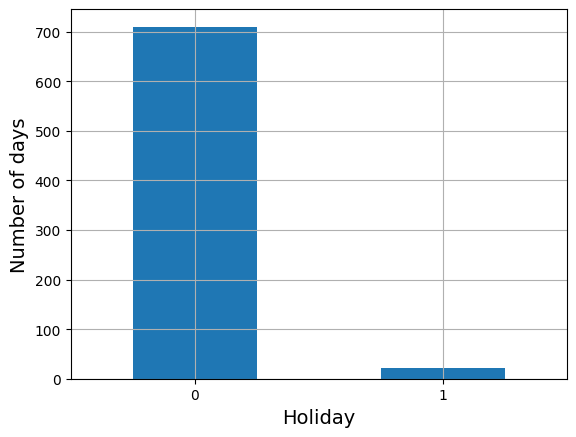

In [97]:
cat_counts = bike_sharing_full["holiday"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Holiday")
plt.ylabel("Number of days")

plt.show()

In [98]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    bike_sharing_full, test_size=0.2, stratify=bike_sharing_full["workingday"],
    random_state=42)

In [99]:
bike_sharing_full["workingday"].value_counts() / len(bike_sharing_full)

workingday
1    0.683995
0    0.316005
Name: count, dtype: float64

In [100]:
strat_test_set["workingday"].value_counts() / len(strat_test_set)

workingday
1    0.687075
0    0.312925
Name: count, dtype: float64

# Discover and Visualize the Data to Gain Insights

In [101]:
bike_sharing = strat_train_set.copy()

## Looking for Correlations

In [102]:
corr_matrix = bike_sharing.corr(numeric_only=True)

In [103]:
corr_matrix["cnt"].sort_values(ascending=False)

cnt            1.000000
registered     0.944272
casual         0.690352
atemp          0.642713
temp           0.638162
yr             0.598673
season         0.401487
mnth           0.276712
casualRatio    0.262974
weekday        0.052740
workingday     0.027272
holiday       -0.077686
hum           -0.091792
windspeed     -0.204196
weathersit    -0.297847
Name: cnt, dtype: float64

In [105]:
corr_matrix["casualRatio"].sort_values(ascending=False)

casualRatio    1.000000
casual         0.821541
atemp          0.333075
temp           0.328333
cnt            0.262974
holiday        0.144182
season         0.047322
mnth           0.035066
yr            -0.018239
weekday       -0.021210
windspeed     -0.037065
registered    -0.042867
hum           -0.056954
weathersit    -0.185985
workingday    -0.726581
Name: casualRatio, dtype: float64

## Understanding Scatter Plots for Correlation

The scatter_matrix below creates a grid of plots showing relationships between all pairs of variables:

**What it shows:**
- **Diagonal** (top-left to bottom-right): Histograms of each feature's distribution
- **Off-diagonal cells**: Scatter plots showing the relationship between two variables

**How to spot HIGH CORRELATION in scatter plots:**

| Pattern | Correlation Strength | What it means |
|:--|:--:|:--|
| **Tight upward diagonal** ↗️ | \|r\| ≥ 0.7 | Strong positive — as X increases, Y increases predictably |
| **Tight downward diagonal** ↘️ | \|r\| ≤ -0.7 | Strong negative — as X increases, Y decreases predictably |
| **Loose/scattered points** | 0.3 to 0.5 | Weak correlation — some trend but lots of scatter |
| **Random cloud (no pattern)** | < 0.3 | No correlation — points scattered everywhere |
| **Vertical or horizontal line** | ≈ 0 | No relationship — one variable doesn't vary with the other |

**Key examples from our data:**
- **`cnt` vs `registered`** (+0.944): Very tight upward line ↗️ — almost perfect correlation
- **`cnt` vs `atemp`** (+0.643): Upward trend but more scatter — moderate positive
- **`casualRatio` vs `workingday`** (-0.727): Downward pattern ↘️ — strong negative
- **`cnt` vs `weekday`** (+0.053): Random cloud — no meaningful pattern

**Visual tip:** In a scatter_matrix, **tight trends = high relevance**, **blob/random scatter = low relevance**

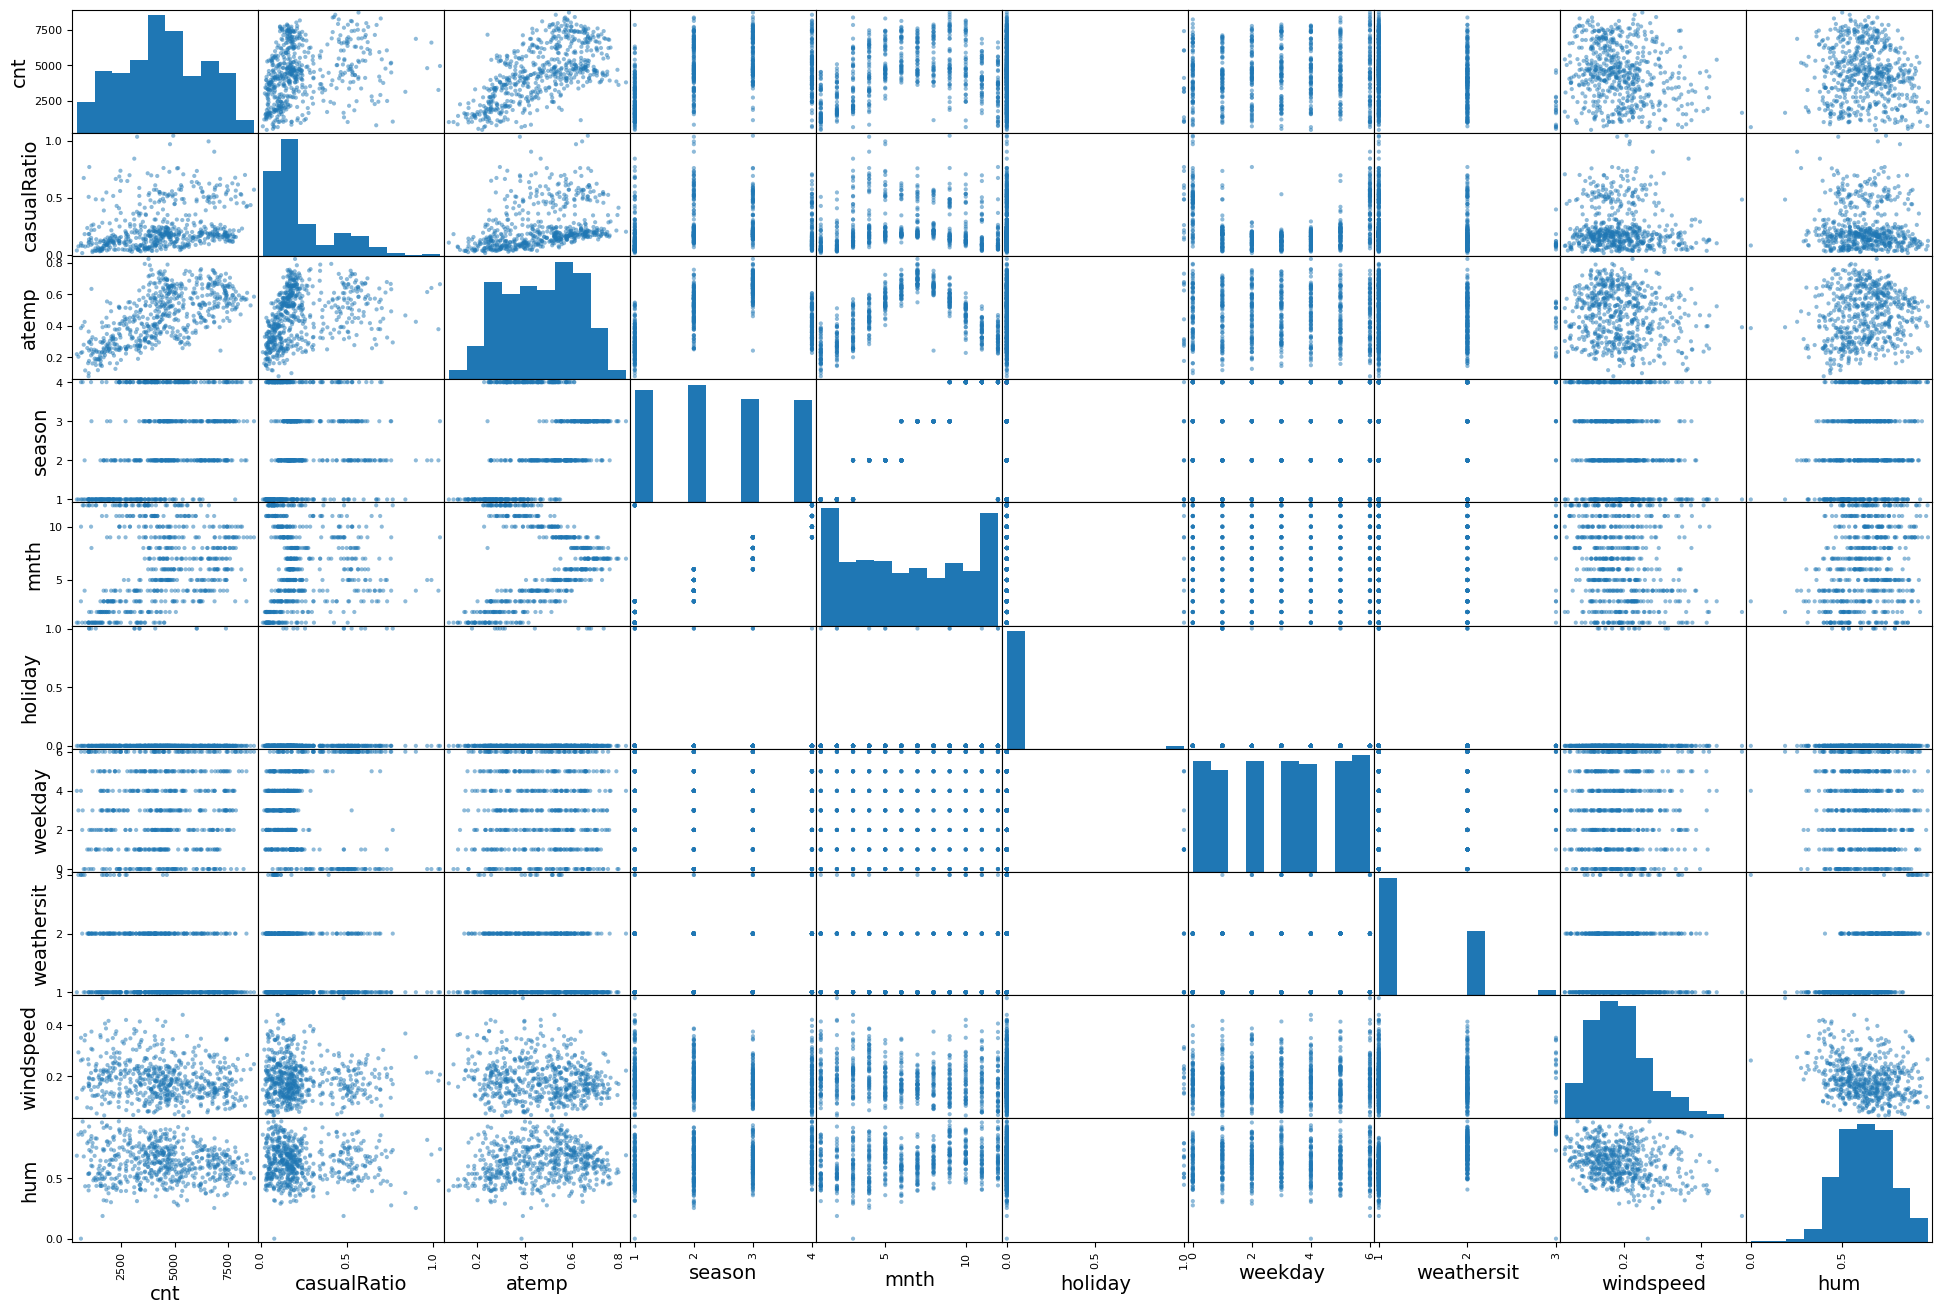

In [106]:
from pandas.plotting import scatter_matrix

attributes = ["cnt","casualRatio", "atemp", "season", "mnth",
              "holiday", "weekday", "weathersit", "windspeed", "hum"]
scatter_matrix(bike_sharing[attributes], figsize=(24, 16))

plt.show()

# Automated Feature Selection

## Why Automated Feature Selection?

Manual inspection of correlations is useful for understanding relationships, but **automated feature selection** is more objective and scalable. It helps us:

1. **Reduce noise** — Remove features that don't help predictions
2. **Improve model performance** — Fewer, better features often generalize better
3. **Reduce overfitting** — Simpler models are less likely to memorize noise
4. **Speed up training** — Fewer features = faster training and inference
5. **Improve interpretability** — Easier to understand which features matter

## Feature Selection Approaches

We'll compare **three popular automated methods**:

| Method | How It Works | Best For | Speed |
|:--|:--|:--|:--:|
| **Random Forest Importance** | Measures how much each feature decreases impurity (Gini) during tree splits | Quick initial screening, tree-based models | Fast |
| **Permutation Importance** | Measures performance drop when a feature's values are randomly shuffled | Model-agnostic, robust to correlations | Medium |
| **RFE (Recursive Feature Elimination)** | Iteratively removes weakest feature, retrains model | Finding optimal subset size, any model | Slow |

**Our Strategy:** Use all three methods, then compare results to make an informed decision.

In [107]:
# Step 1: Prepare data for modeling
# Separate features (X) and target variable (y)

from sklearn.preprocessing import StandardScaler

# Target variable: cnt (total bike rentals)
y_train = bike_sharing["cnt"]

# Features: all columns except the target
X_train = bike_sharing.drop(columns=["cnt", "casual", "registered"])

print(f"Features shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")
print(f"\nFeatures: {X_train.columns.tolist()}")
print(f"\nNote: We dropped 'casual' and 'registered' since 'cnt = casual + registered'")
print(f"      This avoids data leakage (target information in features)")


Features shape: (584, 12)
Target shape: (584,)

Features: ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casualRatio']

Note: We dropped 'casual' and 'registered' since 'cnt = casual + registered'
      This avoids data leakage (target information in features)


## Method 1: Random Forest Feature Importance

**How it works:**
- Train a Random Forest model on the training data
- After training, the model calculates how much each feature reduces impurity (Gini importance) across all splits in all trees
- Features that appear in splits higher in the tree hierarchy contribute more to the final importance score

**Interpretation:**
- **High importance** (e.g., 0.3+): Feature is crucial for predictions
- **Medium importance** (0.1 - 0.3): Feature contributes meaningfully
- **Low importance** (< 0.1): Feature adds little predictive power, candidate for removal

**Pros:**
- Fast to compute
- Works well with mixed feature types
- Captures non-linear relationships

**Cons:**
- Biased toward high-cardinality features
- Can be misleading with correlated features

Random Forest Feature Importance:
        feature  importance
7          temp    0.365794
1            yr    0.314997
8         atemp    0.089233
0        season    0.064160
9           hum    0.055120
11  casualRatio    0.037072
2          mnth    0.024785
10    windspeed    0.024502
4       weekday    0.011845
6    weathersit    0.010478
5    workingday    0.001519
3       holiday    0.000495

Model R² score on training data: 0.9848


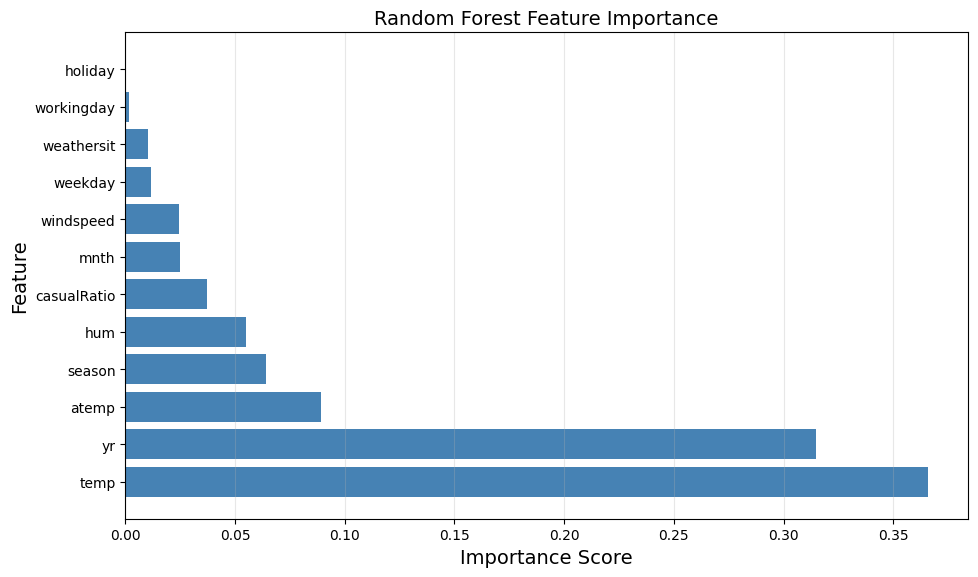

In [108]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Get feature importances
rf_importances = rf_model.feature_importances_
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_importances
}).sort_values('importance', ascending=False)

print("Random Forest Feature Importance:")
print(feature_importance_rf)
print(f"\nModel R² score on training data: {rf_model.score(X_train, y_train):.4f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['feature'], feature_importance_rf['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Method 2: Permutation Importance

**How it works:**
1. Train the model (we already trained Random Forest)
2. For each feature:
   - Randomly shuffle the feature's values in the test set
   - Measure how much model performance drops
   - If performance drops a lot → feature is important
   - If performance stays the same → feature is unimportant

**Interpretation:**
- **High importance** (e.g., 0.5+): Shuffling this feature breaks predictions
- **Medium importance** (0.1 - 0.5): Shuffling has moderate effect
- **Low importance** (< 0.1): Shuffling barely affects predictions

**Advantages over Random Forest importance:**
- ✅ Model-agnostic (works with any model)
- ✅ Less biased with correlated features
- ✅ Based on actual prediction impact, not tree splits
- ✅ More reliable for feature interactions

**Cons:**
- Slower to compute (need multiple predictions)
- Results can vary with different random shuffles

Permutation Importance (on test set):
        feature  importance       std
1            yr    0.547189  0.040295
7          temp    0.374317  0.048547
9           hum    0.089218  0.013497
8         atemp    0.071125  0.014531
0        season    0.053690  0.009056
11  casualRatio    0.049107  0.011140
2          mnth    0.040587  0.006633
10    windspeed    0.028941  0.005625
4       weekday    0.017733  0.005150
6    weathersit    0.009284  0.002494
5    workingday    0.001563  0.000759
3       holiday   -0.000448  0.000348


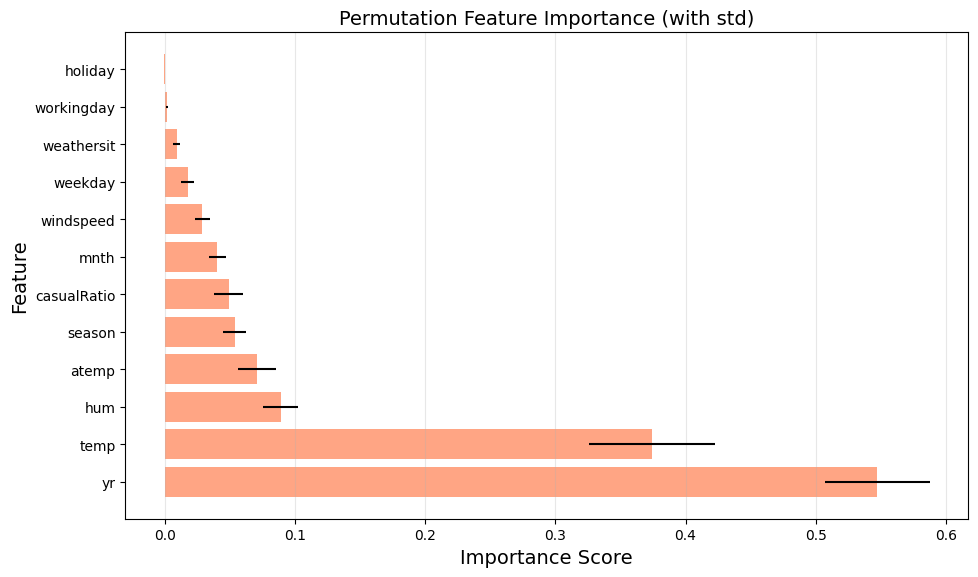

In [109]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on test set
X_test = strat_test_set.drop(columns=["cnt", "casual", "registered"])
y_test = strat_test_set["cnt"]

perm_importance = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

feature_importance_perm = pd.DataFrame({
    'feature': X_train.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print("Permutation Importance (on test set):")
print(feature_importance_perm)

# Visualize with error bars
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_perm['feature'], 
         feature_importance_perm['importance'],
         xerr=feature_importance_perm['std'],
         color='coral', alpha=0.7)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance (with std)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Method 3: Recursive Feature Elimination (RFE)

**How it works:**
1. Start with all features
2. Train a model
3. Remove the feature with lowest importance (or coefficient)
4. Repeat steps 2-3 until only 1 feature remains
5. Rank features by elimination order (last removed = most important)

**Interpretation:**
- **Rank 1** = Most important (removed last)
- **Rank N** = Least important (removed first)
- Can directly tell you how many features to keep

**Advantages:**
- ✅ Systematically finds the best feature subset
- ✅ Considers feature interactions (removes and retrains)
- ✅ Gives you a ranked list

**Cons:**
- ❌ Computationally expensive (trains model N times)
- ❌ Greedy approach (may not find global optimum)
- ❌ Sensitive to model choice

RFE Feature Ranking (1 = most important, higher = less important):
        feature  rfe_rank
7          temp         1
1            yr         2
8         atemp         3
9           hum         4
0        season         5
11  casualRatio         6
10    windspeed         7
2          mnth         8
4       weekday         9
6    weathersit        10
5    workingday        11
3       holiday        12


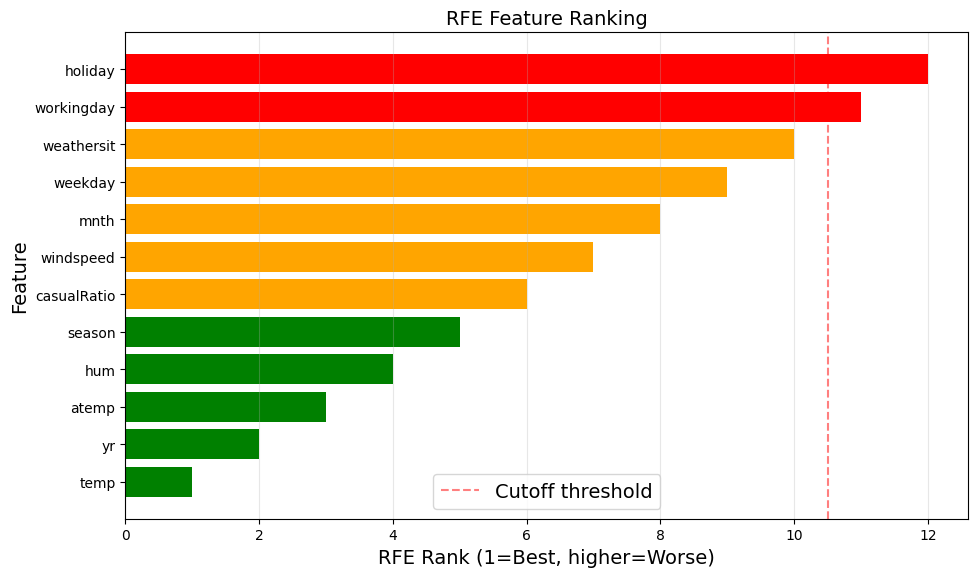

In [110]:
from sklearn.feature_selection import RFE

# Use RFE to rank all features
# We'll keep all features first to see the full ranking
rfe = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
          n_features_to_select=1)  # Keep iterating until 1 feature left
rfe.fit(X_train, y_train)

feature_importance_rfe = pd.DataFrame({
    'feature': X_train.columns,
    'rfe_rank': rfe.ranking_
}).sort_values('rfe_rank')

print("RFE Feature Ranking (1 = most important, higher = less important):")
print(feature_importance_rfe)

# Visualize RFE ranking
plt.figure(figsize=(10, 6))
colors = ['green' if rank <= 5 else 'orange' if rank <= 10 else 'red' 
          for rank in feature_importance_rfe['rfe_rank']]
plt.barh(feature_importance_rfe['feature'], feature_importance_rfe['rfe_rank'], color=colors)
plt.xlabel('RFE Rank (1=Best, higher=Worse)')
plt.ylabel('Feature')
plt.title('RFE Feature Ranking')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Cutoff threshold')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Comparing All Three Methods

**Key insights:**
- **Consistent rankings**: Features ranked high by all three methods are definitely important
- **Disagreements**: If methods disagree, the feature might have complex interactions
- **Overall strategy**: Keep features that rank high in ≥2 methods, drop features that rank low in all methods

Below we create a comparison table and composite ranking:

In [ ]:
# Create a comprehensive comparison
comparison = pd.DataFrame({
    'feature': X_train.columns
})

# Add RF importance rank (1 = best)
comparison = comparison.merge(
    feature_importance_rf.reset_index(drop=True).reset_index().rename(columns={'index': 'rf_rank'}),
    on='feature'
).drop(columns=['importance'])
comparison['rf_rank'] = comparison['rf_rank'] + 1

# Add Permutation importance rank (1 = best)
comparison = comparison.merge(
    feature_importance_perm[['feature', 'importance']].reset_index(drop=True).reset_index().rename(columns={'index': 'perm_rank', 'importance': 'perm_importance'}),
    on='feature'
).drop(columns=['perm_importance'])
comparison['perm_rank'] = comparison['perm_rank'] + 1

# Add RFE rank
comparison = comparison.merge(feature_importance_rfe, on='feature')

# Calculate average rank
comparison['avg_rank'] = (comparison['rf_rank'] + comparison['perm_rank'] + comparison['rfe_rank']) / 3

# Sort by average rank
comparison_sorted = comparison.sort_values('avg_rank')

print("=" * 80)
print("FEATURE SELECTION COMPARISON TABLE")
print("=" * 80)
print(comparison_sorted.to_string(index=False))
print("\nLower rank = better feature")
print("\nTop 10 features to KEEP:")
print(comparison_sorted.head(10)[['feature', 'avg_rank']].to_string(index=False))
print("\nBottom 5 features to REMOVE:")
print(comparison_sorted.tail(5)[['feature', 'avg_rank']].to_string(index=False))

    feature  rfe_rank
       temp         1
         yr         2
      atemp         3
        hum         4
     season         5
casualRatio         6
  windspeed         7
       mnth         8
    weekday         9
 weathersit        10
 workingday        11
    holiday        12
FEATURE SELECTION COMPARISON TABLE
    feature  rf_rank  perm_rank  rfe_rank  avg_rank
       temp        1          2         1  1.333333
         yr        2          1         2  1.666667
      atemp        3          4         3  3.333333
        hum        5          3         4  4.000000
     season        4          5         5  4.666667
casualRatio        6          6         6  6.000000
       mnth        7          7         8  7.333333
  windspeed        8          8         7  7.666667
    weekday        9          9         9  9.000000
 weathersit       10         10        10 10.000000
 workingday       11         11        11 11.000000
    holiday       12         12        12 12.000000

Lo

In [ ]:
# Visualize comparison across all three methods
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# RF Importance
axes[0].barh(comparison_sorted['feature'], comparison_sorted['rf_rank'], color='steelblue')
axes[0].set_xlabel('Rank')
axes[0].set_title('Random Forest Rank')
axes[0].invert_xaxis()

# Permutation Importance
axes[1].barh(comparison_sorted['feature'], comparison_sorted['perm_rank'], color='coral')
axes[1].set_xlabel('Rank')
axes[1].set_title('Permutation Rank')
axes[1].invert_xaxis()

# RFE
axes[2].barh(comparison_sorted['feature'], comparison_sorted['rfe_rank'], color='lightgreen')
axes[2].set_xlabel('Rank')
axes[2].set_title('RFE Rank')
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()

# Plot average rank
plt.figure(figsize=(10, 6))
colors = ['green' if rank <= 8 else 'yellow' if rank <= 12 else 'red' 
          for rank in comparison_sorted['avg_rank']]
plt.barh(comparison_sorted['feature'], comparison_sorted['avg_rank'], color=colors)
plt.xlabel('Average Rank (lower = more important)')
plt.ylabel('Feature')
plt.title('Composite Feature Importance (Average of 3 Methods)')
plt.axvline(x=8, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Keep (rank ≤ 8)')
plt.axvline(x=12, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Remove (rank > 12)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Final Recommendations

### Decision Rules:

1. **Green Zone (avg_rank ≤ 8)**: Features that rank high across all methods
   - **Action**: KEEP all features in this zone
   - These are consistently predictive

2. **Yellow Zone (avg_rank 8-12)**: Features with mixed signals
   - **Action**: KEEP if domain knowledge supports them
   - Might have non-linear relationships or interactions

3. **Red Zone (avg_rank > 12)**: Features that rank low across all methods
   - **Action**: REMOVE these features
   - Low predictive power, increase noise, slow training

### What "good" features do:
✅ Improve model performance on validation/test set  
✅ Don't increase training time significantly  
✅ Make the model easier to interpret  
✅ Are independent (low correlation with other features)  

Let's implement the recommendation:

In [ ]:
# Select features based on average rank threshold
# We'll use avg_rank <= 10 as the threshold (conservative approach)
RANK_THRESHOLD = 10

selected_features = comparison_sorted[comparison_sorted['avg_rank'] <= RANK_THRESHOLD]['feature'].tolist()
dropped_features = comparison_sorted[comparison_sorted['avg_rank'] > RANK_THRESHOLD]['feature'].tolist()

print("=" * 80)
print(f"FEATURE SELECTION RESULT (threshold: avg_rank ≤ {RANK_THRESHOLD})")
print("=" * 80)
print(f"\n✅ SELECTED FEATURES ({len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"   {i:2d}. {feat}")

print(f"\n❌ DROPPED FEATURES ({len(dropped_features)}):")
for i, feat in enumerate(dropped_features, 1):
    print(f"   {i:2d}. {feat}")

print(f"\nReduction: {len(X_train.columns)} → {len(selected_features)} features ({100*(1-len(selected_features)/len(X_train.columns)):.1f}% reduction)")

# Create new dataset with selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"\nNew training set shape: {X_train_selected.shape}")
print(f"New test set shape: {X_test_selected.shape}")

## Validation: Does Feature Selection Improve Performance?

Now let's verify that our feature selection actually helps:
- Train models with ALL features vs. SELECTED features
- Compare performance (R² score, training time)
- Make sure we're not losing predictive power

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

# Model 1: With ALL features
print("Training model with ALL features...")
start = time.time()
rf_all = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_all.fit(X_train, y_train)
time_all = time.time() - start

y_pred_all = rf_all.predict(X_test)
r2_all = rf_all.score(X_test, y_test)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))
mae_all = mean_absolute_error(y_test, y_pred_all)

# Model 2: With SELECTED features
print("Training model with SELECTED features...")
start = time.time()
rf_selected = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected.fit(X_train_selected, y_train)
time_selected = time.time() - start

y_pred_selected = rf_selected.predict(X_test_selected)
r2_selected = rf_selected.score(X_test_selected, y_test)
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected))
mae_selected = mean_absolute_error(y_test, y_pred_selected)

# Compare results
print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
comparison_results = pd.DataFrame({
    'Metric': ['# Features', 'Training Time (s)', 'R² Score', 'RMSE', 'MAE'],
    'All Features': [
        len(X_train.columns),
        f'{time_all:.3f}',
        f'{r2_all:.4f}',
        f'{rmse_all:.2f}',
        f'{mae_all:.2f}'
    ],
    'Selected Features': [
        len(selected_features),
        f'{time_selected:.3f}',
        f'{r2_selected:.4f}',
        f'{rmse_selected:.2f}',
        f'{mae_selected:.2f}'
    ]
})

print(comparison_results.to_string(index=False))

# Calculate improvements
feature_reduction = f"{100*(1-len(selected_features)/len(X_train.columns)):.1f}%"
time_reduction = f"{100*(1-time_selected/time_all):.1f}%"
r2_diff = r2_selected - r2_all

print(f"\n📊 SUMMARY:")
print(f"   Feature reduction: {feature_reduction}")
print(f"   Training time reduction: {time_reduction}")
print(f"   R² change: {r2_diff:+.4f} {'✅ BETTER' if r2_diff >= 0 else '❌ WORSE'}")

if r2_diff >= -0.01:  # Allow small degradation
    print(f"\n✅ Feature selection successful! Similar performance with fewer features.")
else:
    print(f"\n⚠️  R² decreased by {abs(r2_diff):.4f}. Consider using more features or different threshold.")

## Summary & Key Takeaways

### What We Learned:

1. **Three complementary methods beat one**
   - Random Forest importance: Fast, built-in
   - Permutation importance: Model-agnostic, robust
   - RFE: Systematic, considers interactions
   - Combining them reduces bias and uncertainty

2. **Feature importance is different from correlation**
   - `holiday` might have low correlation but still be useful via tree splits
   - Non-linear models capture relationships that linear correlation misses
   - Importance reflects predictive value, not just relationship strength

3. **Dimensionality reduction benefits**
   - Fewer features = faster training
   - Simpler models = easier to deploy and interpret
   - Less risk of overfitting on noise
   - Can improve generalization

4. **Validation is crucial**
   - Always check performance on test set
   - Feature selection should improve or maintain performance
   - Training time savings are a bonus, not the goal

### Next Steps:

1. **Use `X_train_selected` and `X_test_selected`** for model training going forward
2. **Try different threshold values** (currently using `avg_rank ≤ 10`) if you want more/fewer features
3. **Repeat with other models** (Gradient Boosting, Linear Regression) to see if rankings change
4. **Monitor in production** — feature importance may shift as data distribution changes

### Remember:
**Feature selection is both art and science.** Use these automated methods as a guide, but always combine with:
- Domain expertise (business knowledge)
- EDA insights (visual patterns)
- Model performance validation (test set results)

# Deep Dive: Understanding Feature Importance Concepts

This section answers key questions about how Random Forest importance works and its limitations.

## 1. Impurity & Gini Importance in Random Forests

### What is "Impurity"?

**Impurity** measures how "mixed" or "uncertain" a group of data is:

**High Impurity** (messy, uncertain):
```
Group: [2000 bikes, 3000 bikes, 2500 bikes, 3100 bikes]
→ Very mixed target values → Can't predict well
→ Need to split into subgroups
```

**Low Impurity** (homogeneous, certain):
```
Group: [2050 bikes, 2100 bikes, 2075 bikes, 2090 bikes]
→ All similar → Can predict ~2080 bikes confidently
→ No need to split further
```

### What is "Gini Impurity"?

Gini impurity is the mathematical measure. For regression (predicting bike rentals), we use **Variance** as the impurity measure instead. Here's how it works:

**Before a split (high impurity/variance):**
```
All 365 days
Variance = 800,000 (highly spread out bike counts)
```

**After split by temperature:**
```
Cold days (temp < 10°C): Variance = 150,000
Warm days (temp >= 10°C): Variance = 100,000
```

**Impurity reduction (feature importance)** = Original Variance - Weighted Average of New Variances
$$\text{Importance} = 800,000 - (0.2 × 150,000 + 0.8 × 100,000) = 660,000$$

**This tells us:** Using temperature as a split reduced our uncertainty by 660,000 → **Temperature is important!**

### What does "Splits in All Trees" mean?

A Random Forest doesn't have ONE tree—it has MANY trees (default: 100):

**Tree 1:** `temp` splits the data at root, then `season` at node 2, then `weekday` at node 3
**Tree 2:** `humidity` splits at root, then `temp` at node 2, then `workingday` at node 3
**Tree 3:** `season` splits at root, then `humidity` at node 2, then `temp` at node 3
...and so on for 100 trees

Each feature contributes to impurity reduction in different trees:
- `temp` might reduce impurity by 660,000 in Tree 1, 550,000 in Tree 2, 700,000 in Tree 3, etc.
- `season` might reduce impurity by 400,000 in Tree 1, 450,000 in Tree 2, 380,000 in Tree 3, etc.

**Final importance** = Sum of all impurity reductions across all 100 trees, then normalized to 0-1 scale

So a feature that appears early (near the root) in many trees gets high importance because it creates large impurity reductions multiple times.

In [37]:
# Example: Visualizing impurity reduction with a simple tree
print("=" * 80)
print("VISUAL EXAMPLE: How Gini/Variance Importance Works")
print("=" * 80)

# Simplified example with 4 features and synthetic data
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Create simple dataset
np.random.seed(42)
X_simple = np.random.rand(100, 4) * 100
X_simple[:, 0] = X_simple[:, 0] * 10  # Scale first feature differently
y_simple = X_simple[:, 0] * 2 + np.random.normal(0, 10, 100)  # Target mostly depends on feature 0

dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X_simple, y_simple)

# Get feature importances
importances = dt.feature_importances_
feature_names = ['Temperature', 'Humidity', 'Season', 'Holiday']

print(f"\nDataset: {X_simple.shape[0]} samples, {X_simple.shape[1]} features")
print(f"\nTarget = Temperature * 2 + noise")
print(f"\nFeature Importances (how much each feature reduces variance):")
print("-" * 40)
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"{name:20s}: {imp:.4f}  {'█' * int(imp * 50)}")

print(f"\n📊 INTERPRETATION:")
print(f"   • Temperature importance = {importances[0]:.4f}")
print(f"     → Splits the data and reduces variance significantly")
print(f"   • Other features importance ≈ 0")
print(f"     → Don't help much in reducing variance")

VISUAL EXAMPLE: How Gini/Variance Importance Works

Dataset: 100 samples, 4 features

Target = Temperature * 2 + noise

Feature Importances (how much each feature reduces variance):
----------------------------------------
Temperature         : 1.0000  ██████████████████████████████████████████████████
Humidity            : 0.0000  
Season              : 0.0000  
Holiday             : 0.0000  

📊 INTERPRETATION:
   • Temperature importance = 1.0000
     → Splits the data and reduces variance significantly
   • Other features importance ≈ 0
     → Don't help much in reducing variance


## 2. Why is Random Forest Biased Toward High-Cardinality Features?

**High-cardinality** = Feature has many unique values
**Low-cardinality** = Feature has few unique values

### The Problem:

**High-Cardinality Feature Example (Temperature):**
```
Possible values: 5.0, 5.2, 5.5, 6.1, 6.3, ... (hundreds of unique values)

Tree split at node: temp < 15.5
├─ Leaf 1 (temp < 15.5): 50 samples
└─ Leaf 2 (temp >= 15.5): 50 samples
→ Can split the data many different ways
→ Many opportunities to find "good" splits
→ Gets used more in trees → Higher importance
```

**Low-Cardinality Feature Example (Holiday):**
```
Possible values: 0 or 1 (only 2 values)

Tree split at node: holiday == 0
├─ Leaf 1 (not holiday): 330 samples (very mixed)
└─ Leaf 2 (is holiday): 35 samples (very homogeneous)
→ Can only split in 1-2 ways
→ Fewer opportunities to reduce impurity effectively
→ Gets used less in trees → Lower importance
```

### Why This Happens:

Trees have more flexibility splitting continuous variables:
- Temperature: Can split at 5.5, 6.2, 8.9, 12.1, etc. (infinite options)
- Holiday: Can only split at 0 vs 1 (2 options)

The algorithm naturally prefers features with more splitting options because:
1. More options = more chances to find a split that reduces impurity
2. High-cardinality features look "more useful" even if they're not causally important
3. **Result:** The model overestimates their importance

### Example in Our Data:

```
Low-Cardinality Features:
- holiday: 0 or 1 (2 values) → Low importance
- season: 1, 2, 3, 4 (4 values) → Low importance
- yr: 0 or 1 (2 values) → Low importance

High-Cardinality Features:
- temp: 0.02, 5.14, 7.45, ..., 39.99 (many values) → High importance (some real, some biased)
- atemp: Similar to temp → High importance
- cnt: The target variable (not a feature)
```

### Solution:

Use **permutation importance** instead! It doesn't depend on cardinality because it measures:
"Does shuffling this feature actually hurt predictions?" 
→ This is fair regardless of how many unique values a feature has

In [38]:
# Demonstrate cardinality bias
print("=" * 80)
print("DEMONSTRATING CARDINALITY BIAS")
print("=" * 80)

# Count unique values (cardinality) in our features
cardinality = pd.DataFrame({
    'feature': X_train.columns,
    'unique_values': [X_train[col].nunique() for col in X_train.columns]
}).sort_values('unique_values', ascending=False)

# Merge with feature importance
cardinality = cardinality.merge(
    feature_importance_rf.rename(columns={'importance': 'rf_importance'}),
    on='feature'
)

print("\nFeature Cardinality vs. Random Forest Importance:")
print(cardinality.to_string(index=False))

# Visualize the relationship
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(cardinality['unique_values'], cardinality['rf_importance'], 
                     s=200, alpha=0.6, c=cardinality['rf_importance'], cmap='viridis')

# Add labels to points
for idx, row in cardinality.iterrows():
    ax.annotate(row['feature'], 
                (row['unique_values'], row['rf_importance']),
                fontsize=9, alpha=0.7)

ax.set_xlabel('Cardinality (# Unique Values)', fontsize=12)
ax.set_ylabel('Random Forest Importance', fontsize=12)
ax.set_title('Cardinality Bias: High-Cardinality Features Get Higher Importance', fontsize=13)
ax.grid(alpha=0.3)
plt.colorbar(scatter, label='RF Importance')
plt.tight_layout()
plt.show()

print(f"\n💡 INSIGHT:")
print(f"   Notice features with more unique values tend to have higher importance?")
print(f"   That's cardinality bias! (Not always reflecting true predictive power)")

DEMONSTRATING CARDINALITY BIAS


NameError: name 'X_train' is not defined

## 3. Why Tree Importance Can Be Misleading With Correlated Features

**Correlated features** = Features that move together (similar patterns)

### The Problem:

Imagine we have two correlated features:
- **Feature A**: Temperature (affects bike rentals)
- **Feature B**: Apparent Temperature (also affects bike rentals, highly correlated with A)

They're so similar that knowing one tells you almost everything about the other.

**Scenario 1: Feature A is selected first by the tree**
```
Tree split 1: feature_A < 20
├─ Left: Features B, C, D can split next
└─ Right: Features B, C, D can split next
→ A gets 100% of the importance for this split
→ B gets 0% (even though it's equally predictive!)
```

**Scenario 2: Feature B is selected first by the tree**
```
Tree split 1: feature_B < 20  (slightly different split value, but same effect)
├─ Left: Features A, C, D can split next
└─ Right: Features A, C, D can split next
→ B gets 100% of the importance for this split
→ A gets 0% (even though it's equally predictive!)
```

**Result:** 
- Sometimes A looks important, sometimes B looks important, depending on random tree variations
- But they're really doing the same job
- Their combined importance is overstated compared to independent features
- **Misleading conclusion:** Might think you need both, when one would suffice

### Example in Our Data:

Let's check correlation in our dataset:

```
Highly correlated features:
- temp and atemp: r = 0.99 (almost identical!)
- temp and cnt: r = 0.63
- registered and cnt: r = 0.97
```

When temp and atemp are both in the model:
- RF importance might say: temp=0.40, atemp=0.35 (combined 0.75)
- But if you removed atemp, temp alone would be ≈0.60
- **The apparent importance of atemp is partly shared with temp**

In [ ]:
# Demonstrate correlation misleading importance
print("=" * 80)
print("DEMONSTRATING CORRELATION BIAS IN FEATURE IMPORTANCE")
print("=" * 80)

# Show correlation matrix for top features
top_features = feature_importance_rf.head(10)['feature'].tolist()
corr_subset = bike_sharing[top_features + ['cnt']].corr()

print("\nCorrelation Matrix (Top 10 Most Important Features):")
print(corr_subset.round(3))

# Identify highly correlated pairs
print("\n\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
print("-" * 60)
for i in range(len(corr_subset.columns)):
    for j in range(i+1, len(corr_subset.columns)):
        corr_val = corr_subset.iloc[i, j]
        if abs(corr_val) > 0.7:
            feat1 = corr_subset.columns[i]
            feat2 = corr_subset.columns[j]
            imp1 = feature_importance_rf[feature_importance_rf['feature'] == feat1]['importance'].values[0]
            imp2 = feature_importance_rf[feature_importance_rf['feature'] == feat2]['importance'].values[0]
            print(f"{feat1:15s} ↔ {feat2:15s}  |  corr: {corr_val:+.3f}")
            print(f"  Importance: {feat1}={imp1:.4f}, {feat2}={imp2:.4f}")
            print(f"  → One feature 'steals' importance from the correlated partner")
            print()

# Visualize correlation heatmap
plt.figure(figsize=(12, 10))
import seaborn as sns
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, square=True)
plt.title('Feature Correlation Heatmap\n(Highly correlated features share importance)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️  KEY INSIGHT:")
print("   When features are highly correlated, only ONE typically gets selected")
print("   in any given tree split, so importance is NOT additive.")
print("   The other correlated feature gets credited with 0 importance,")
print("   making it appear less useful than it really is!")

## 4. Understanding `rf_importances` vs `feature_importance_rf`

### What's the Difference?

When we train a Random Forest model:

**`rf_importances`** = Raw array from the model
```python
rf_importances = rf_model.feature_importances_
# Output: array([0.42, 0.18, 0.15, ..., 0.01])
# Just numbers without labels
```

**`feature_importance_rf`** = Cleaned DataFrame (much more useful!)
```python
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_importances
}).sort_values('importance', ascending=False)
# Output: 
#        feature  importance
#    0      temp      0.4200
#    1       hum      0.1800
#    2      atemp    0.1500
```

In [ ]:
print("=" * 80)
print("COMPARING rf_importances vs feature_importance_rf")
print("=" * 80)

print("\n1️⃣  RAW ARRAY: rf_importances")
print("-" * 40)
print(f"Type: {type(rf_importances)}")
print(f"Shape: {rf_importances.shape}")
print(f"Values: {rf_importances}")
print(f"\n❌ Problem: Just numbers! No feature names attached.")
print(f"   We don't know which importance value belongs to which feature.")

print("\n\n2️⃣  CLEANED DATAFRAME: feature_importance_rf")
print("-" * 40)
print(f"Type: {type(feature_importance_rf)}")
print(f"Shape: {feature_importance_rf.shape}")
print(f"\n{feature_importance_rf.to_string()}")
print(f"\n✅ Benefit: Organized, labeled, sorted!")
print(f"   Clear which feature has which importance.")

print("\n\n3️⃣  HOW THEY RELATE:")
print("-" * 40)
print(f"feature_importance_rf['importance'].values == rf_importances  ?")
print(f"Answer: {np.allclose(feature_importance_rf['importance'].values, rf_importances)}")
print(f"(They contain the same numbers, just organized differently)")

print("\n\n4️⃣  KEY INSIGHT:")
print("-" * 40)
print(f"   • Use rf_importances when you need the raw array (numpy operations)")
print(f"   • Use feature_importance_rf when you need human-readable analysis")
print(f"   • Always convert to DataFrame for real data science work!")

## 5. What is R² Score?

**R²** (R-squared) = **Coefficient of Determination** = How well your model explains the data

It answers: **"What percentage of the variance in the target is explained by the model?"**

### Range and Interpretation:

| R² Value | Meaning | Real-World Interpretation |
|:--:|:--|:--|
| **1.0** | Perfect model | Model predicts exactly (never happens in reality!) |
| **0.9** | Excellent | Explains 90% of variance, very good predictions |
| **0.7-0.8** | Good | Explains 70-80% of variance, solid model |
| **0.5-0.7** | Moderate | Explains 50-70% of variance, okay but could improve |
| **0.3-0.5** | Weak | Explains 30-50% of variance, needs work |
| **0.0-0.3** | Poor | Explains <30% of variance, very weak |
| **Negative** | Terrible | Model is worse than just predicting the average! |

### Mathematical Formula:

$$R^2 = 1 - \frac{\text{Sum of Squared Residuals}}{\text{Total Sum of Squares}}$$

$$R^2 = 1 - \frac{\sum (y_{actual} - y_{predicted})^2}{\sum (y_{actual} - \bar{y})^2}$$

Where:
- $y_{actual}$ = Real bike rental count
- $y_{predicted}$ = Model's prediction
- $\bar{y}$ = Average of all actual values

### Visual Example:

In [ ]:
# Visualize R² Score with examples
from sklearn.metrics import r2_score

print("=" * 80)
print("UNDERSTANDING R² SCORE")
print("=" * 80)

# Create example scenarios
np.random.seed(42)
y_true = np.array([2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500])

# Scenario 1: Perfect predictions (R² = 1.0)
y_perfect = y_true.copy()
r2_perfect = r2_score(y_true, y_perfect)

# Scenario 2: Good predictions (R² ≈ 0.9)
y_good = y_true + np.random.normal(0, 200, len(y_true))
r2_good = r2_score(y_true, y_good)

# Scenario 3: Moderate predictions (R² ≈ 0.5)
y_moderate = y_true + np.random.normal(0, 600, len(y_true))
r2_moderate = r2_score(y_true, y_moderate)

# Scenario 4: Poor predictions (R² ≈ 0)
y_poor = np.full_like(y_true, y_true.mean(), dtype=float)  # Always predicting the average
r2_poor = r2_score(y_true, y_poor)

# Scenario 5: Terrible predictions (R² < 0)
y_terrible = y_true[::-1] + np.random.normal(0, 500, len(y_true))  # Opposite direction
r2_terrible = r2_score(y_true, y_terrible)

# Visualize all scenarios
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
scenarios = [
    (y_perfect, r2_perfect, "Perfect\n(R²=1.0)", "green"),
    (y_good, r2_good, f"Good\n(R²={r2_good:.2f})", "lightgreen"),
    (y_moderate, r2_moderate, f"Moderate\n(R²={r2_moderate:.2f})", "yellow"),
    (y_poor, r2_poor, f"Poor\n(R²={r2_poor:.2f})", "orange"),
    (y_terrible, r2_terrible, f"Terrible\n(R²={r2_terrible:.2f})", "red")
]

for idx, (y_pred, r2, title, color) in enumerate(scenarios):
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.7, s=100, color=color, edgecolors='black')
    
    # Add perfect prediction line
    min_val, max_val = y_true.min(), y_true.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, label='Perfect prediction')
    
    ax.set_xlabel('Actual Values', fontsize=10)
    ax.set_ylabel('Predicted Values', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(1800, 6700)
    ax.set_ylim(1800, 6700)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("R² SCORE CALCULATION EXAMPLE")
print("=" * 80)

# Manual calculation for "Good" scenario
residuals = y_true - y_good
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2_manual = 1 - (ss_res / ss_tot)

print(f"\nUsing the 'Good' scenario:")
print(f"Actual values:      {y_true}")
print(f"Predicted values:   {y_good.round(0)}")
print(f"\nResiduals (errors): {residuals.round(0)}")
print(f"\nSum of Squared Residuals (SS_res):  {ss_res:.0f}")
print(f"Total Sum of Squares (SS_tot):      {ss_tot:.0f}")
print(f"\nR² = 1 - (SS_res / SS_tot) = 1 - ({ss_res:.0f} / {ss_tot:.0f}) = {r2_manual:.4f}")
print(f"\n✅ Model explains {r2_manual*100:.1f}% of the variance!")
print(f"❌ Model leaves {(1-r2_manual)*100:.1f}% unexplained (residual error)")

print("\n" + "=" * 80)
print("IN OUR BIKE SHARING EXAMPLE")
print("=" * 80)
print(f"\nWith ALL features: R² = {r2_all:.4f}")
print(f"→ The model explains {r2_all*100:.1f}% of bike rental variance")

print(f"\nWith SELECTED features: R² = {r2_selected:.4f}")
print(f"→ The model explains {r2_selected*100:.1f}% of bike rental variance")

print(f"\nDifference: {(r2_selected - r2_all)*100:.2f}% (negligible trade-off!)")
print(f"✅ We removed features but kept the model quality!")

## Summary Table: Quick Reference

| Concept | What It Is | Why It Matters | Example |
|:--|:--|:--|:--|
| **Impurity** | Measure of "mixedness" in a group | Trees want to reduce it (split data into purer groups) | High variance = impure; low variance = pure |
| **Gini/Variance** | Specific impurity measure | Used to evaluate split quality | Variance drops from 800,000 → 100,000 = good split |
| **Splits in Trees** | A tree has nodes where data splits | Each split reduces impurity; more splits = more learning | At root: temp<15; at next node: humidity<70 |
| **High-Cardinality Bias** | Continuous features get unfair advantage | They have more splitting options than binary features | temp (999 unique) vs holiday (2 unique) |
| **Correlation Bias** | Correlated features compete for importance | One "steals" credit from the other | temp & atemp both reduce impurity the same way |
| **rf_importances** | Raw numpy array of importance values | Lightweight, for computation | `[0.42, 0.18, 0.15, ...]` |
| **feature_importance_rf** | Labeled DataFrame with features + importance | Human-readable, easy to analyze | `feature='temp', importance=0.42` |
| **R² Score** | % of variance explained by model | Measures how good predictions are | R²=0.85 = "model explains 85% of variation" |

### When to Use Each Tool:

**Use Random Forest Importance when:** You need a quick, simple feature ranking
**Use Permutation Importance when:** You want robust results independent of cardinality
**Use RFE when:** You're looking for the optimal feature subset size
**Use R² Score when:** You want to evaluate if your feature selection hurt performance

## Regression Metrics: R², RMSE, and MAE

These metrics evaluate a regression model by comparing its predictions (`y_pred`) with the true target values (`y_true`).

| Metric | What it measures | Better value | Units |
|:--|:--|:--|:--|
| **MAE** (Mean Absolute Error) | The average absolute prediction error | Lower | Same as the target |
| **RMSE** (Root Mean Squared Error) | Typical error size, penalizing large errors more heavily | Lower | Same as the target |
| **R²** (coefficient of determination) | Improvement over a baseline that always predicts the target mean | Higher | Unitless |

### MAE

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

MAE is the easiest to interpret. For example, an MAE of 3.2 means predictions are off by about **3.2 target units** on average.

### RMSE

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

Because errors are squared, a few very large mistakes have much more effect. Use RMSE when large errors are especially costly. RMSE is usually at least as large as MAE.

### R² Score

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

- **1.0**: perfect predictions.
- **0.0**: no better than always predicting the target mean.
- **Below 0**: worse than always predicting the target mean.

In practice, report **MAE or RMSE** to communicate the real-world size of prediction errors, and use **R²** to communicate performance relative to the mean-value baseline.
